In [1]:
# Run this cell immediately after restarting the kernel, before importing NumPy.
import os
for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
                 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[variable] = '1'

%cd /global/homes/l/lonappan/workspace/cosmic_birefringence
#%pip install -e . -q
%matplotlib inline
import itertools
import numpy as np
import matplotlib.pyplot as plt
from cosmic_bire import CBlike
from cosmic_bire.relcal import RelCal

config = 'configs/planck_hfi.yml'
mask = '0'          # same mask as the MK chain you compare against
ref = '353B'        # gauge: alpha_ref = 0 for both estimators

rc = RelCal(config, mask=mask)
labels = [rc.map_label(k) for k in range(rc.nmaps)]
print('maps:', labels)
print('f_sky:', rc.f_sky, '| bins:', rc.n_bins, f'| ell {rc.l_min}-{rc.l_max-1}, dl={rc.l_bin}')

/global/u2/l/lonappan/workspace/cosmic_birefringence
maps: ['100A', '143A', '217A', '353A', '100B', '143B', '217B', '353B']
f_sky: 0.9164005073512961 | bins: 72 | ell 51-1490, dl=20


## Pairwise fits
Exact one-parameter likelihood per pair (no small-angle approximation). Same-frequency A$\times$B pairs are foreground-cancellation-exact; cross-frequency pairs rely only on band-to-band correlation of the dust $EB$ template.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

100Ax143A   Dalpha =  -0.3066 +- 0.1199 deg
100Ax217A   Dalpha =  -0.3552 +- 0.1307 deg
100Ax353A   Dalpha =  -0.0880 +- 0.1688 deg
100Ax100B   Dalpha =  +0.1051 +- 0.1487 deg  <- same-frequency A x B
100Ax143B   Dalpha =  -0.4522 +- 0.1168 deg
100Ax217B   Dalpha =  -0.2327 +- 0.1303 deg
100Ax353B   Dalpha =  -0.2231 +- 0.1741 deg
143Ax217A   Dalpha =  +0.1359 +- 0.0650 deg
143Ax353A   Dalpha =  +0.2019 +- 0.0704 deg
143Ax100B   Dalpha =  +0.4835 +- 0.1088 deg
143Ax143B   Dalpha =  -0.1002 +- 0.0712 deg  <- same-frequency A x B
143Ax217B   Dalpha =  +0.0369 +- 0.0650 deg
143Ax353B   Dalpha =  +0.2360 +- 0.0734 deg
217Ax353A   Dalpha =  +0.1366 +- 0.0319 deg
217Ax100B   Dalpha =  +0.3885 +- 0.1195 deg
217Ax143B   Dalpha =  -0.2587 +- 0.0635 deg
217Ax217B   Dalpha =  +0.0618 +- 0.0383 deg  <- same-frequency A x B
217Ax353B   Dalpha =  +0.1653 +- 0.0348 deg
353Ax100B   Dalpha =  +0.3727 +- 0.1555 deg
353Ax143B   Dalpha =  -0.4219 +- 0.0687 deg
353Ax217B   Dalpha =  -0.1074 +- 0.0318 deg
3

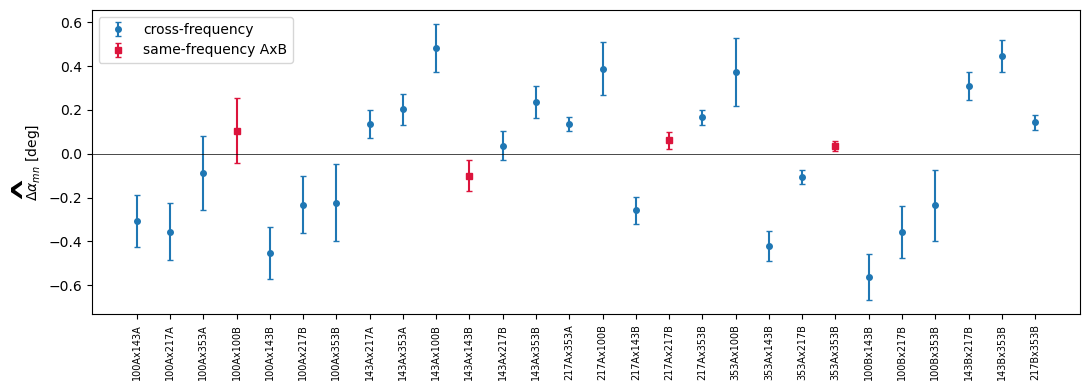

In [2]:
pair_fits = rc.fit_all_pairs()

names = [f'{a}x{b}' for (a, b) in pair_fits]
vals = np.array([v[0] for v in pair_fits.values()])
errs = np.array([v[1] for v in pair_fits.values()])
same_freq = np.array([a[:-1] == b[:-1] for (a, b) in pair_fits])

for (a, b), (v, s) in pair_fits.items():
    tag = '  <- same-frequency A x B' if a[:-1] == b[:-1] else ''
    print(f'{a}x{b:6s} Dalpha = {v:+8.4f} +- {s:6.4f} deg{tag}')

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(names))
ax.errorbar(x[~same_freq], vals[~same_freq], errs[~same_freq], fmt='o', ms=4, capsize=2, label='cross-frequency')
ax.errorbar(x[same_freq], vals[same_freq], errs[same_freq], fmt='s', ms=5, capsize=2, color='crimson', label='same-frequency AxB')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=90, fontsize=7)
ax.set_ylabel(r'$\widehat{\Delta\alpha}_{mn}$ [deg]'); ax.legend()
fig.tight_layout()
fig.savefig(rc.paths['plots'] / f'relcal_pairs_mask_{mask}.pdf')

## Triangle closure (internal null)
$\widehat{\Delta\alpha}_{mn}+\widehat{\Delta\alpha}_{np}+\widehat{\Delta\alpha}_{pm}=0$ must hold for any systematic that is a per-map rotation. Failures flag asymmetric systematics (transfer-function A/B mismatch, bandpass leakage, frequency-dependent dust angles). Naive-quadrature sigmas overestimate significance because triangles share spectra; treat this as a ranking, confirm outliers on sims.

In [3]:
d = dict(pair_fits)
def delta(a, b):
    if (a, b) in d: return d[(a, b)]
    v = d[(b, a)]; return (-v[0], v[1])

tri = []
for a, b, c in itertools.combinations(labels, 3):
    t = delta(a, b)[0] + delta(b, c)[0] + delta(c, a)[0]
    s = np.sqrt(delta(a, b)[1]**2 + delta(b, c)[1]**2 + delta(c, a)[1]**2)
    tri.append((f'{a}-{b}-{c}', t, t / s))

tri.sort(key=lambda r: -abs(r[2]))
print(f'{len(tri)} triangles; worst 10 by |closure/sigma_naive|:')
for name, t, z in tri[:10]:
    print(f'  {name:18s} {t:+8.4f} deg  ({z:+5.2f})')

56 triangles; worst 10 by |closure/sigma_naive|:
  143A-217A-217B      +0.1609 deg  (+1.62)
  143A-143B-217B      +0.1715 deg  (+1.49)
  353A-100B-143B      +0.2320 deg  (+1.16)
  143A-353A-143B      -0.1198 deg  (-0.99)
  100A-143B-353B      +0.2165 deg  (+0.98)
  100A-143A-217A      +0.1845 deg  (+0.98)
  143A-143B-353B      +0.1094 deg  (+0.88)
  100A-217A-143B      -0.1617 deg  (-0.87)
  100A-353A-353B      +0.1706 deg  (+0.70)
  143A-217A-353A      +0.0706 deg  (+0.70)


## Network fit
Small-angle GLS over all 28 pairs with the full analytic pair covariance (eigenmode-projected inverse; the common dust template makes the per-bin pair covariance near-singular). Gauge fixed to $\alpha_{\rm ref}=0$ so the recovered parameters are directly comparable to the MK differences $\alpha_m-\alpha_{\rm ref}$.

In [4]:
alpha_rel, cov_rel, _ = rc.fit_network(ref=ref)
err_rel = np.sqrt(np.abs(np.diag(cov_rel)))
for k in range(rc.nmaps):
    print(f'{labels[k]:5s} alpha - alpha_{ref} = {alpha_rel[k]:+8.4f} +- {err_rel[k]:6.4f} deg')

100A  alpha - alpha_353B =  -0.0450 +- 0.0969 deg
143A  alpha - alpha_353B =  +0.2524 +- 0.0605 deg
217A  alpha - alpha_353B =  +0.1715 +- 0.0381 deg
353A  alpha - alpha_353B =  +0.0367 +- 0.0302 deg
100B  alpha - alpha_353B =  -0.1621 +- 0.0896 deg
143B  alpha - alpha_353B =  +0.4015 +- 0.0592 deg
217B  alpha - alpha_353B =  +0.1445 +- 0.0382 deg
353B  alpha - alpha_353B =  +0.0000 +- 0.0194 deg


## Load the MK chain from `mcmc.ipynb`
Same config, same mask. `getdist_samples()` reads the live HDF chain with the configured burn-in/thinning; columns are `[beta, alpha_100A..353A, alpha_100B..353B, A_0..A_3]` in degrees, identical map ordering to `RelCal`.

In [5]:
lh = CBlike(config)
_ = lh.getdist_samples()
samples = lh.samples
print('chain samples:', samples.shape)
mk_alpha = samples[:, 1:1 + rc.nmaps]
mk_mean, mk_cov = mk_alpha.mean(0), np.cov(mk_alpha.T)
print('beta =', f"{samples[:,0].mean():+.4f} +- {samples[:,0].std():.4f} deg")

Loaded 218368 samples directly from /global/homes/l/lonappan/pscratch/CBDATA/chains/planck_hfi_mask_0.h5
Removed no burn in
chain samples: (218368, 13)
beta = +0.3723 +- 0.1166 deg


## Closure test
$d_m = (\alpha_m^{\rm rel}-\alpha_{\rm ref}^{\rm rel}) - (\alpha_m^{\rm MK}-\alpha_{\rm ref}^{\rm MK})$.
The reference fixes the otherwise arbitrary common offset in both methods; only the differences are observable, so the comparison is done in a shared gauge. The MK angle differences inherit the $A_\ell\sin 4\psi_\ell$ dust ansatz; $\alpha^{\rm rel}$ does not. A significant $d$ localizes a dust-model (or asymmetric-systematic) bias in the MK network, which propagates to $\beta$ through $\bar\alpha+\beta=\rm const$. Naive sigmas ignore the estimator-chain correlation (same 56 spectra): the calibrated covariance of $d$ comes from the sims cell at the end.

In [6]:
res = rc.closure_vs_mk(samples, ref=ref)
print(f'{"map":5s} {"rel":>9s} {"MK":>9s} {"d":>9s}   naive z')
for k in range(rc.nmaps):
    print(f"{res['labels'][k]:5s} {res['alpha_rel'][k]:+9.4f} {res['alpha_mk'][k]:+9.4f} "
          f"{res['d'][k]:+9.4f}   {res['naive_sigma'][k]:+5.2f}")

map         rel        MK         d   naive z
100A    -0.0450   -0.0922   +0.0472   +0.37
143A    +0.2524   +0.2500   +0.0024   +0.03
217A    +0.1715   +0.1636   +0.0079   +0.17
353A    +0.0367   +0.0372   -0.0006   -0.02
100B    -0.1621   -0.1974   +0.0353   +0.30
143B    +0.4015   +0.3700   +0.0315   +0.41
217B    +0.1445   +0.1438   +0.0007   +0.02
353B    +0.0000   +0.0000   +0.0000   +0.00


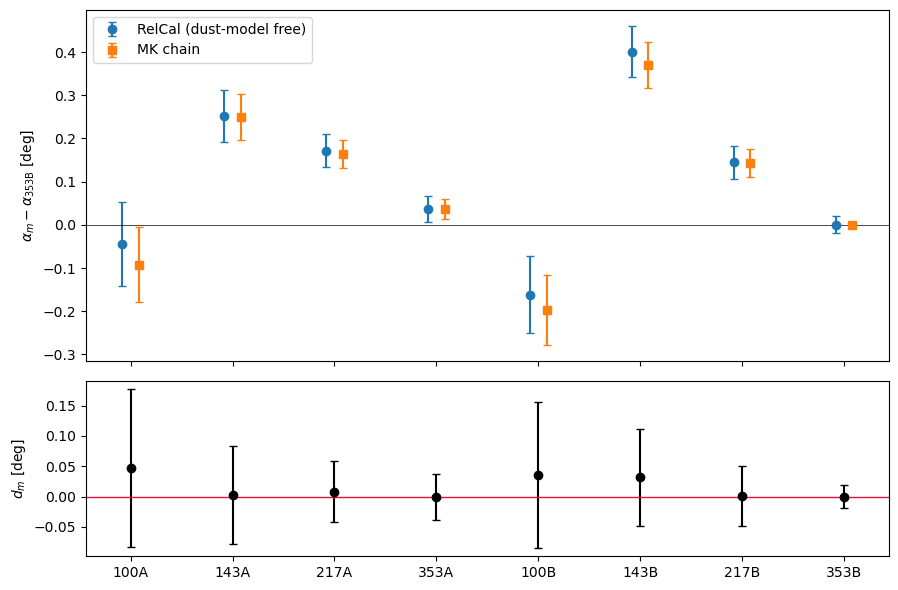

In [7]:
kref = labels.index(ref)
mk_rel = mk_mean - mk_mean[kref]
mk_rel_err = np.sqrt(np.abs(np.diag(mk_cov) + mk_cov[kref, kref] - 2 * mk_cov[:, kref]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
x = np.arange(rc.nmaps)
ax1.errorbar(x - 0.08, alpha_rel, err_rel, fmt='o', capsize=3, label='RelCal (dust-model free)')
ax1.errorbar(x + 0.08, mk_rel, mk_rel_err, fmt='s', capsize=3, label='MK chain')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_ylabel(rf'$\alpha_m-\alpha_{{\rm {ref}}}$ [deg]'); ax1.legend()
ax2.errorbar(x, res['d'], np.sqrt(err_rel**2 + mk_rel_err**2), fmt='o', color='k', capsize=3)
ax2.axhline(0, color='crimson', lw=1)
ax2.set_ylabel('$d_m$ [deg]'); ax2.set_xticks(x); ax2.set_xticklabels(labels)
fig.tight_layout()
fig.savefig(rc.paths['plots'] / f'relcal_closure_mask_{mask}.pdf')

corr = 0.984


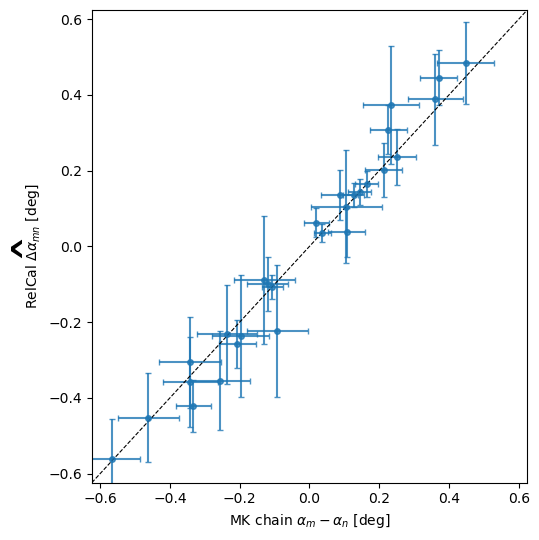

In [8]:
# pair-level version: 28 MK posterior differences vs 28 RelCal pairwise fits
xs, ys, xe, ye = [], [], [], []
for (a, b), (v, s) in pair_fits.items():
    ia, ib = labels.index(a), labels.index(b)
    xs.append(mk_mean[ia] - mk_mean[ib])
    xe.append(np.sqrt(mk_cov[ia, ia] + mk_cov[ib, ib] - 2 * mk_cov[ia, ib]))
    ys.append(v); ye.append(s)
xs, ys, xe, ye = map(np.array, (xs, ys, xe, ye))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.errorbar(xs, ys, xerr=xe, yerr=ye, fmt='o', ms=4, capsize=2, alpha=0.8)
lim = 1.1 * max(np.abs(np.r_[xs, ys]).max(), 1e-3)
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
ax.set(xlabel=r'MK chain $\alpha_m-\alpha_n$ [deg]', ylabel=r'RelCal $\widehat{\Delta\alpha}_{mn}$ [deg]',
       xlim=(-lim, lim), ylim=(-lim, lim))
print('corr =', f'{np.corrcoef(xs, ys)[0, 1]:.3f}')
fig.tight_layout()
fig.savefig(rc.paths['plots'] / f'relcal_pair_scatter_mask_{mask}.pdf')

## Robustness: 30% Galactic mask
The dust-cancellation argument predicts mask-stable $\Delta\alpha$ even though the dust amplitude changes by a large factor. The MK $\alpha$'s shifted with the mask in EK22 when the dust $EB$ was ignored; $\widehat{\Delta\alpha}$ should not.

In [9]:
rc30 = RelCal(config, mask='30')
alpha30, cov30, _ = rc30.fit_network(ref=ref)
err30 = np.sqrt(np.abs(np.diag(cov30)))
for k in range(rc.nmaps):
    dm = alpha_rel[k] - alpha30[k]
    print(f'{labels[k]:5s} mask0 {alpha_rel[k]:+8.4f}  mask30 {alpha30[k]:+8.4f}  diff {dm:+8.4f} deg')

100A  mask0  -0.0450  mask30  -0.0867  diff  +0.0416 deg
143A  mask0  +0.2524  mask30  +0.2561  diff  -0.0036 deg
217A  mask0  +0.1715  mask30  +0.0521  diff  +0.1194 deg
353A  mask0  +0.0367  mask30  -0.0653  diff  +0.1020 deg
100B  mask0  -0.1621  mask30  -0.2285  diff  +0.0664 deg
143B  mask0  +0.4015  mask30  +0.2751  diff  +0.1263 deg
217B  mask0  +0.1445  mask30  +0.0083  diff  +0.1362 deg
353B  mask0  +0.0000  mask30  +0.0000  diff  -0.0000 deg


## Calibrated closure covariance from NPIPE simulations
Run both pipelines on simulation spectra produced by the same `Spectra` pipeline (fill in your sim file pattern). This yields the joint covariance of $d$ that the naive sigmas above cannot provide, and validates the analytic RelCal errors against NaMaster/mask coupling.

In [ ]:
# sim_files = sorted(Path('...').glob('cl_sim_*.npy'))
# d_sims = []
# for f in sim_files:
#     a_s, c_s, _ = RelCal.fit_from_file(config, f, mask=mask, ref=ref)
#     chi2_s, p_s = lh.analysis.return_likelihood()          # MK ML fit on the same sim
#     mk_s = np.degrees(p_s[1:1 + rc.nmaps])                 # check column order of your minimizer
#     d_sims.append((a_s - a_s[labels.index(ref)]) - (mk_s - mk_s[labels.index(ref)]))
# d_sims = np.array(d_sims)
# cov_d = np.cov(d_sims.T)
# z = np.linalg.solve(np.linalg.cholesky(cov_d + 1e-12*np.eye(rc.nmaps)), res['d'])
# print('closure chi2 =', float(z @ z), 'for', rc.nmaps - 1, 'dof')